# 02 — PySpark Preprocessing & Feature Engineering

This notebook walks through the PySpark-based preprocessing stage and the feature engineering decisions. Everything here is automated in `src/pipeline.py`; this notebook exists to explain the *why* behind each decision.

In [1]:
import sys, os
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from features import engineer_features, FEATURE_COLUMNS, INTERACTION_PAIRS


## 1. Load data

In [2]:
df = pd.read_csv("../data/creditcard.csv")
print(f"Shape: {df.shape}")


Shape: (284807, 31)


## 2. PySpark preprocessing

### Why PySpark?

This dataset is 284K rows — pandas handles it fine. But the pipeline is designed for production, where the same code must handle 10× or 100× the data without rewriting. PySpark's DataFrame API scales horizontally without code changes.

**What PySpark does here:**
- Null audit across all columns
- StandardScaler on Amount and Time (V1–V28 arrive already PCA-scaled)
- Stratified partitioning for the train/test split

In `pipeline.py`, this stage auto-detects PySpark availability and falls back to pandas if needed.

In [3]:
try:
    from pyspark.sql import SparkSession
    spark = (SparkSession.builder
             .appName("fraud_eda_preprocessing")
             .config("spark.driver.memory", "2g")
             .config("spark.sql.shuffle.partitions", "4")
             .getOrCreate())
    spark.sparkContext.setLogLevel("ERROR")

    sdf = spark.createDataFrame(df)
    print(f"PySpark DataFrame: {sdf.count():,} rows × {len(sdf.columns)} columns")
    print("\nSchema:")
    sdf.printSchema()

    from pyspark.sql.functions import isnull, col, sum as spark_sum
    cols_to_check = ["Time", "Amount", "Class"] + [f"V{i}" for i in range(1, 29)]
    null_expr = [spark_sum(isnull(col(c)).cast("int")).alias(c) for c in cols_to_check]
    null_counts = sdf.agg(*null_expr).collect()[0].asDict()
    total_nulls = sum(null_counts.values())
    print(f"\nTotal nulls: {total_nulls}")
    if total_nulls == 0:
        print("✓ No null values found — dataset is clean")

    spark.stop()
    PYSPARK_AVAILABLE = True

except ImportError:
    print("PySpark not installed in this environment.")
    print("Demonstrating null audit with pandas:")
    null_counts = df.isnull().sum()
    total_nulls = null_counts.sum()
    print(f"Total nulls: {total_nulls}")
    if total_nulls == 0:
        print("✓ No null values found — dataset is clean")
    PYSPARK_AVAILABLE = False


PySpark not installed in this environment.
Demonstrating null audit with pandas:
Total nulls: 0
✓ No null values found — dataset is clean


## 3. Feature engineering

### Decision 1: log1p transform on Amount

Amount is heavily right-skewed — a few very large transactions dominate. `log1p` compresses the tail so the model does not over-index on magnitude outliers.

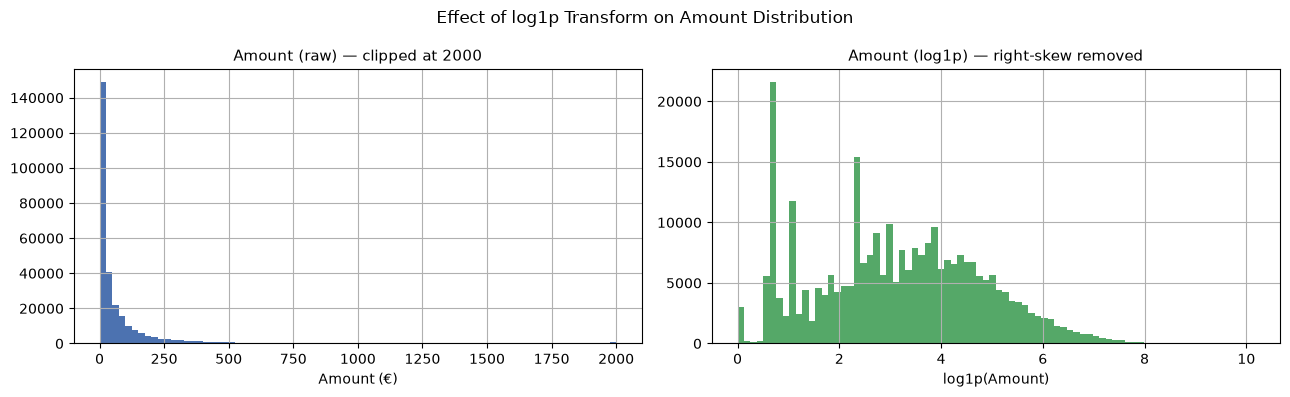

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["Amount"].clip(upper=2000).hist(bins=80, ax=axes[0], color="#4C72B0", edgecolor="none")
axes[0].set_title("Amount (raw) — clipped at 2000", fontsize=11)
axes[0].set_xlabel("Amount (€)")

np.log1p(df["Amount"]).hist(bins=80, ax=axes[1], color="#55A868", edgecolor="none")
axes[1].set_title("Amount (log1p) — right-skew removed", fontsize=11)
axes[1].set_xlabel("log1p(Amount)")

plt.suptitle("Effect of log1p Transform on Amount Distribution", fontsize=12)
plt.tight_layout()
plt.show()


### Decision 2: Cyclical encoding of Time

Time is in seconds from the first transaction and spans ~48 hours. If we model it linearly, 23:59 and 00:01 appear at opposite ends of the axis. Cyclical encoding (`sin`/`cos` of hour-within-day) keeps time-of-day structure intact.

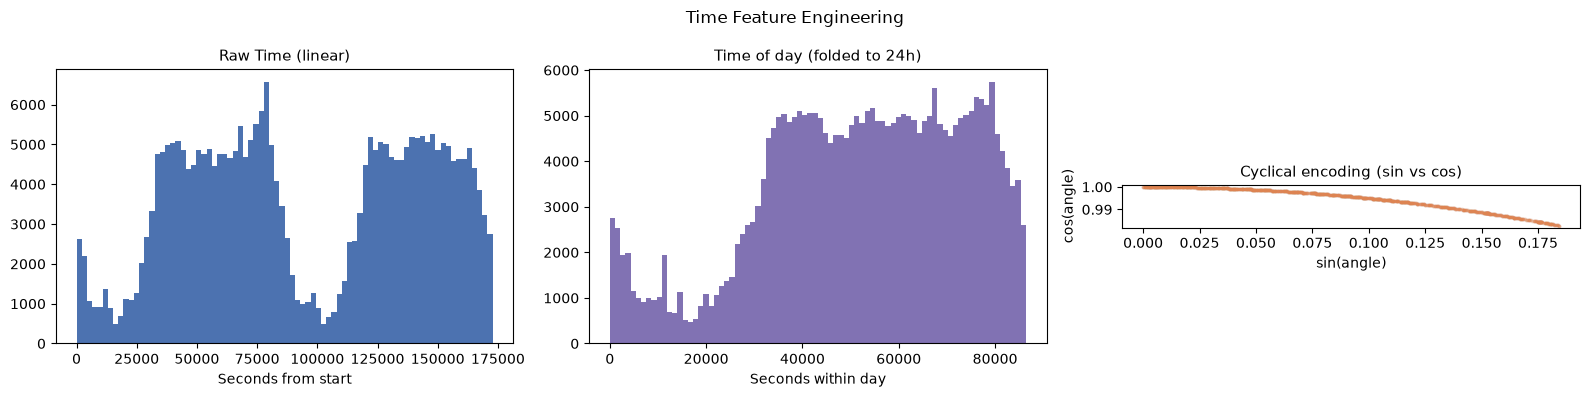

In [5]:
seconds_in_day = 86_400
time_of_day = df["Time"] % seconds_in_day
angle = 2 * np.pi * time_of_day / seconds_in_day

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["Time"], bins=80, color="#4C72B0", edgecolor="none")
axes[0].set_title("Raw Time (linear)", fontsize=11)
axes[0].set_xlabel("Seconds from start")

axes[1].hist(time_of_day, bins=80, color="#8172B3", edgecolor="none")
axes[1].set_title("Time of day (folded to 24h)", fontsize=11)
axes[1].set_xlabel("Seconds within day")

axes[2].scatter(np.sin(angle)[:3000], np.cos(angle)[:3000],
                alpha=0.1, s=3, color="#DD8452")
axes[2].set_title("Cyclical encoding (sin vs cos)", fontsize=11)
axes[2].set_xlabel("sin(angle)")
axes[2].set_ylabel("cos(angle)")
axes[2].set_aspect("equal")

plt.suptitle("Time Feature Engineering", fontsize=12)
plt.tight_layout()
plt.show()


### Decision 3: V-feature interaction products

PCA features (V1–V28) are orthogonal by construction, so linear models cannot capture their interactions. XGBoost handles non-linearities via tree splits, but explicit interaction products can still improve AUC-PR by giving the model a direct signal for joint patterns.

We add the top-5 pairwise products identified by correlation with the fraud label.

In [6]:
from features import compute_top_v_pairs
print("Computing top V-feature pairs by correlation with fraud label…")
top_pairs = compute_top_v_pairs(df, top_n=8)
print("\nTop 8 pairs (by |correlation| of product with Class):")
for a, b in top_pairs:
    prod = df[a] * df[b]
    corr = prod.corr(df["Class"])
    print(f"  {a} × {b}  →  correlation = {corr:+.4f}")


Computing top V-feature pairs by correlation with fraud label…

Top 8 pairs (by |correlation| of product with Class):
  V12 × V14  →  correlation = +0.5827
  V4 × V14  →  correlation = -0.5749
  V11 × V14  →  correlation = -0.5532
  V14 × V16  →  correlation = +0.5488
  V10 × V12  →  correlation = +0.5486
  V16 × V17  →  correlation = +0.5446
  V12 × V17  →  correlation = +0.5428
  V14 × V17  →  correlation = +0.5425


## 4. Apply full feature engineering

In [7]:
df_engineered = engineer_features(df)
available_features = [c for c in FEATURE_COLUMNS if c in df_engineered.columns]

print(f"Feature set: {len(available_features)} columns")
print("\nSample of engineered features:")
df_engineered[["Amount", "Amount_log", "Time", "Time_sin", "Time_cos",
               "V14_x_V17", "V12_x_V14"]].head(5).round(4)


Feature set: 36 columns

Sample of engineered features:


,Amount,Amount_log,Time,Time_sin,Time_cos,V14_x_V17,V12_x_V14
0,149.62,5.0148,0.0,0.0000,1.0,-0.0647,0.1922
1,2.69,1.3056,0.0,0.0000,1.0,0.0165,-0.1532
2,378.66,5.9393,1.0,0.0001,1.0,-0.1842,-0.0110
3,123.50,4.8243,1.0,0.0001,1.0,0.1970,-0.0513
4,69.99,4.2625,2.0,0.0001,1.0,0.2654,-0.6026


## 5. Scaler hygiene — no leakage

The StandardScaler (used on Amount and Time in the PySpark stage) is **fitted only on the training fold** and then applied to both train and test. This is enforced in `pipeline.py` by fitting after the stratified split.

SMOTE is also applied only to the training fold — never to test data.